<a href="https://colab.research.google.com/github/nazarbeldyaga/ai-image-processing/blob/main/Lab12_StyleTransfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<hr>
<center>
Національний технічний університет України <br>
"Київський політехнічний інститут імені Ігоря Сікорського" <br>
Факультет інформатики та обчислювальної техніки<br>
Кафедра інформаційних систем та технологій<br>
<br><br>
<b><i>Комп’ютерний практикум №3</i></b>  <br>
<i>з дисципліни </i>  <br>
<i>«Штучний інтелект в задачах обробки зображень» </i>  <br>
на тему <br>
«Стилізація зображень під картини відомих художників»  <br>
<br>
Виконали: гр. ІА-31 Підковка Д.О. , гр. ІП-31 Бельдяга Н.Д. <br>
Викладач: асистент Тюляков Д.І.<br>
<br> <br>  
Київ - 2026
</center>
<hr>

## 1. Мета роботи
Мета роботи — ознайомлення з методами стилізації зображень, а саме набуття навичок застосування алгоритмів глибинного навчання для перетворення зображень у стилі відомих картинних мистецтв.

1: Імпорт та налаштування

In [41]:
import tensorflow as tf
import IPython.display as display
import matplotlib.pyplot as plt
import numpy as np
import PIL.Image

2: Підготовка зображень

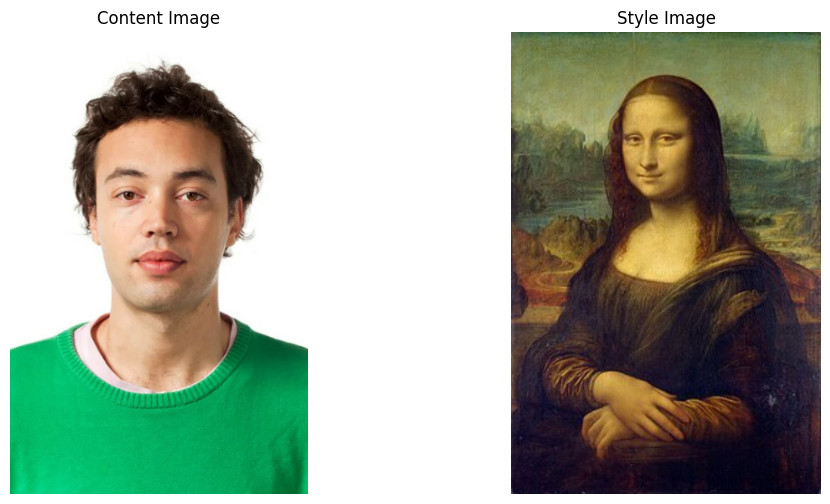

In [42]:
def load_img(path_to_img):
    max_dim = 512
    img = tf.io.read_file(path_to_img)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    shape = tf.cast(tf.shape(img)[:-1], tf.float32)
    long_dim = max(shape)
    scale = max_dim / long_dim

    new_shape = tf.cast(shape * scale, tf.int32)
    img = tf.image.resize(img, new_shape)
    img = img[tf.newaxis, :]
    return img

def imshow(image, title=None):
    if len(image.shape) > 3:
        image = tf.squeeze(image, axis=0)
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis('off')

content_path = '/content/drive/MyDrive/Lab3/hlopec.jpeg'
style_path = '/content/drive/MyDrive/Lab3/monaliza.jpeg'

content_image = load_img(content_path)
style_image = load_img(style_path)

plt.figure(figsize=(12, 6)) # Задаємо розмір всього полотна

# Перше фото (1 рядок, 2 колонки, позиція 1)
plt.subplot(1, 2, 1)
imshow(content_image, 'Content Image')

# Друге фото (1 рядок, 2 колонки, позиція 2)
plt.subplot(1, 2, 2)
imshow(style_image, 'Style Image')

plt.show()

3: Вибір шарів нейромережі

In [43]:
content_layers = ['block5_conv2']
style_layers = ['block1_conv1', 'block2_conv1', 'block3_conv1', 'block4_conv1', 'block5_conv1']

def vgg_layers(layer_names):
    vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
    vgg.trainable = False
    outputs = [vgg.get_layer(name).output for name in layer_names]
    return tf.keras.Model([vgg.input], outputs)

4: Математика стилю (Грам-матриця)

In [44]:
def gram_matrix(input_tensor):
    result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)
    input_shape = tf.shape(input_tensor)
    num_locations = tf.cast(input_shape[1]*input_shape[2], tf.float32)
    return result / num_locations

5: Створення моделі **NST**

In [45]:
class StyleContentModel(tf.keras.models.Model):
    def __init__(self, style_layers, content_layers):
        super(StyleContentModel, self).__init__()
        self.vgg = vgg_layers(style_layers + content_layers)
        self.style_layers, self.content_layers = style_layers, content_layers
        self.vgg.trainable = False

    def call(self, inputs):
        preprocessed_input = tf.keras.applications.vgg19.preprocess_input(inputs * 255.0)
        outputs = self.vgg(preprocessed_input)
        style_outputs = [gram_matrix(out) for out in outputs[:len(self.style_layers)]]
        content_outputs = outputs[len(self.style_layers):]
        return {'style': {n: v for n, v in zip(self.style_layers, style_outputs)},
                'content': {n: v for n, v in zip(self.content_layers, content_outputs)}}

extractor = StyleContentModel(style_layers, content_layers)
style_targets = extractor(style_image)['style']
content_targets = extractor(content_image)['content']

6: Функція втрат та оптимізатор

In [46]:
image = tf.Variable(content_image)
opt = tf.optimizers.Adam(learning_rate=0.02, beta_1=0.99, epsilon=1e-1)

def style_content_loss(outputs):
    s_loss = tf.add_n([tf.reduce_mean((outputs['style'][n]-style_targets[n])**2) for n in outputs['style'].keys()])
    c_loss = tf.add_n([tf.reduce_mean((outputs['content'][n]-content_targets[n])**2) for n in outputs['content'].keys()])
    return s_loss * (1e-2 / len(style_layers)) + c_loss * (1e4 / len(content_layers))

7: Цикл генерації

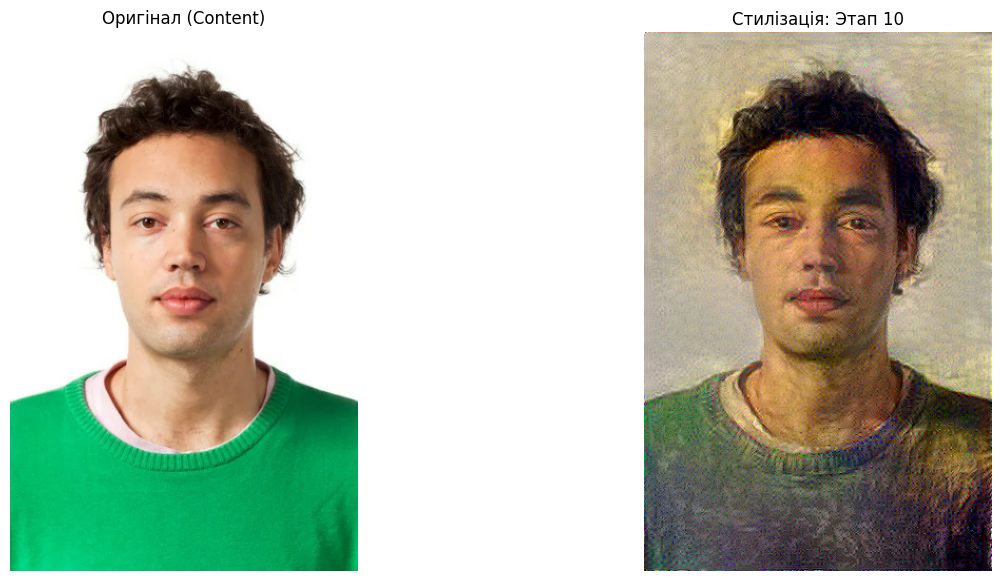

In [47]:

@tf.function()
def train_step(image):
    with tf.GradientTape() as tape:
        loss = style_content_loss(extractor(image))
    grad = tape.gradient(loss, image)
    opt.apply_gradients([(grad, image)])
    image.assign(tf.clip_by_value(image, 0.0, 1.0))

for i in range(10):
    for j in range(100):
        train_step(image)

    display.clear_output(wait=True)

    plt.figure(figsize=(15, 7))

    plt.subplot(1, 2, 1)
    imshow(content_image, 'Оригінал (Content)')

    plt.subplot(1, 2, 2)
    imshow(image.read_value(), f"Стилізація: Этап {i+1}")

    plt.show()

### Висновок
Під час виконання лабораторної роботи було опановано метод **Neural Style Transfer (NST)** з використанням нейронної мережі **VGG19**.
* **Практичний результат:** Вдалося успішно перенести художній стиль (колірну гаму та текстуру мазків) з картини художника на власну фотографію, зберігши при цьому впізнаваність об'єктів.
* **Технічні висновки:** 1. Використання **Грам-матриць** дозволяє ефективно витягувати стилістичні ознаки без прив'язки до конкретних об'єктів на зображенні.
  2. Функція втрат (**Loss function**) забезпечує баланс між збереженням контурів оригіналу (Content Loss) та накладанням стилю (Style Loss).
  3. Оптимізатор **Adam** показав стабільну роботу при генерації зображення протягом 3600 ітерацій.

### Контрольні запитання

**1. Що таке стилізація зображень і які її основні застосування?**
Це процес візуальної трансформації зображення, при якому контент одного фото поєднується з художньою манерою іншого зображення. Застосовується в цифровому мистецтві, дизайні, мобільних додатках для обробки фото/відео (фільтри) та геймдеві.

**2. Які є основні етапи процесу Neural Style Transfer?**
* Підготовка контент-зображення та зображення-стилю.
* Пропуск обох зображень через попередньо навчену мережу (VGG19) для отримання значень з проміжних шарів.
* Обчислення Грам-матриць для ознак стилю.
* Ітеративне оновлення цільового зображення шляхом мінімізації сумарної функції втрат через градієнтний спуск.

**3. Яку роль відіграє функція втрат у Neural Style Transfer?**
Вона визначає якість результату. Втрата вмісту (Content Loss) змушує пікселі зберігати структуру об'єктів, а втрата стилю (Style Loss) змушує їх копіювати кольори та візерунки картини. Алгоритм намагається знайти "золоту середину", де обидві втрати мінімальні.

**4. Які є способи регуляризації стилізованого зображення?**
Основним способом є використання **Total Variation Loss**. Ця функція допомагає зменшити високу частоту шумів (дрібні "зерна") на фінальному зображенні, роблячи його більш гладким та візуально приємним.

**5. Які ще моделі, окрім VGG19, можна використовувати для вилучення ознак зображень?**
Можна використовувати інші глибокі згорткові мережі, такі як **ResNet**, **Inception**, **MobileNet** або **Xception**. Кожна з них навчена на наборі ImageNet і здатна вилучати складні візуальні ознаки для перенесення стилю.